# ERA5 Winter Windstorm Hazard — Belgium (2000–2024)


In [1]:
# data loading 
import xarray as xr
import pandas as pd
from pathlib import Path


BASE_DIRS = [
    Path("/Users/axelleclaes/Desktop/wetransfer_thesis_2025-11-07_0852"),
    Path("/Users/axelleclaes/Desktop/Data België"),
]

FILE_SPECS = [
    ("wind_gust_00_03", "wind_gust_00_03"),
    ("wind_gust_04_07", "wind_gust_04_07"),
    ("wind_gust_08_11", "wind_gust_08_11"),
    ("wind_gust_12_14", "wind_gust_12_14"),
    ("2015", "2015/data_stream-oper_stepType-max.nc"),
    ("2016", "2016/data_stream-oper_stepType-max.nc"),
    ("2017", "2017/data_stream-oper_stepType-max.nc"),
    ("2018", "2018/data_stream-oper_stepType-max.nc"),
    ("2019", "2019/data_stream-oper_stepType-max.nc"),
    ("2020", "2020/data_stream-oper_stepType-max.nc"),
    ("2021", "2021/data_stream-oper_stepType-max.nc"),
    ("2022", "2022/data_stream-oper_stepType-max.nc"),
    ("2023", "2023/data_stream-oper_stepType-max.nc"),
    ("2024", "2024/data_stream-oper_stepType-max.nc"),
]

def find_existing_file(relative_path, base_dirs):
    """Find a file in a list of base directories"""
    rel = Path(relative_path)
    tried = []
    for base in base_dirs:
        candidate = base / rel
        tried.append(str(candidate))
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "file not found. try:\n- " + "\n- ".join(tried)
    )

def standardize_dataset(ds, label="dataset"):
    """make dataset consister."""
    rename_map = {}
    if "time" in ds.coords and "valid_time" not in ds.coords:
        rename_map["time"] = "valid_time"
    if "lon" in ds.coords and "longitude" not in ds.coords:
        rename_map["lon"] = "longitude"
    if "lat" in ds.coords and "latitude" not in ds.coords:
        rename_map["lat"] = "latitude"
    if rename_map:
        ds = ds.rename(rename_map)

    if "valid_time" not in ds.coords:
        raise KeyError(
            f"{label}: no 'valid_time' or 'time' found. "
            f"avaialbe coords: {list(ds.coords)}"
        )

    ds = ds.assign_coords(valid_time=pd.to_datetime(ds["valid_time"].values))

    if "expver" in ds.dims:
        ds = ds.isel(expver=0, drop=True)

    return ds.sortby("valid_time")

datasets = []
resolved_files = []

for label, rel_path in FILE_SPECS:
    file_path = find_existing_file(rel_path, BASE_DIRS)
    ds = xr.open_dataset(file_path)
    ds = standardize_dataset(ds, label=label)
    datasets.append(ds)
    resolved_files.append((label, str(file_path)))

ds_combined_BE = xr.concat(datasets, dim="valid_time").sortby("valid_time")

print("Loaded files:")
for label, file_path in resolved_files:
    print(f"  - {label}: {file_path}")

print("\nLoaded. Variables:", list(ds_combined_BE.data_vars))
print("Coördinates:", list(ds_combined_BE.coords))
print("valid_time dtype:", ds_combined_BE["valid_time"].dtype)
print("Time limit:", str(ds_combined_BE["valid_time"].values[0]), "→", str(ds_combined_BE["valid_time"].values[-1]))


Loaded files:
  - wind_gust_00_03: /Users/axelleclaes/Desktop/wetransfer_thesis_2025-11-07_0852/wind_gust_00_03
  - wind_gust_04_07: /Users/axelleclaes/Desktop/wetransfer_thesis_2025-11-07_0852/wind_gust_04_07
  - wind_gust_08_11: /Users/axelleclaes/Desktop/wetransfer_thesis_2025-11-07_0852/wind_gust_08_11
  - wind_gust_12_14: /Users/axelleclaes/Desktop/wetransfer_thesis_2025-11-07_0852/wind_gust_12_14
  - 2015: /Users/axelleclaes/Desktop/Data België/2015/data_stream-oper_stepType-max.nc
  - 2016: /Users/axelleclaes/Desktop/Data België/2016/data_stream-oper_stepType-max.nc
  - 2017: /Users/axelleclaes/Desktop/Data België/2017/data_stream-oper_stepType-max.nc
  - 2018: /Users/axelleclaes/Desktop/Data België/2018/data_stream-oper_stepType-max.nc
  - 2019: /Users/axelleclaes/Desktop/Data België/2019/data_stream-oper_stepType-max.nc
  - 2020: /Users/axelleclaes/Desktop/Data België/2020/data_stream-oper_stepType-max.nc
  - 2021: /Users/axelleclaes/Desktop/Data België/2021/data_stream-oper_s

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap
from scipy.interpolate import RegularGridInterpolator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from shapely.geometry import mapping
from matplotlib.path import Path
import matplotlib.patches as mpatches
from matplotlib.patches import PathPatch

mpl.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Helvetica Neue', 'Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size':         8,
    'axes.titlesize':    9,
    'axes.labelsize':    8,
    'xtick.labelsize':   7,
    'ytick.labelsize':   7,
    'legend.fontsize':   7,
    'axes.linewidth':    0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.major.size':  3,
    'ytick.major.size':  3,
    'xtick.direction':   'out',
    'ytick.direction':   'out',
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.grid':         False,
    'figure.dpi':        180,
    'savefig.dpi':       300,
    'savefig.facecolor': 'white',
    'savefig.bbox':      'tight',
})

THRESHOLD     = 22.22
WINTER_MONTHS = [1, 2, 3, 10, 11, 12]
PROJ          = ccrs.PlateCarree()
LON_MIN, LON_MAX = 2.25, 6.65
LAT_MIN, LAT_MAX = 49.35, 51.75
KYRILL_DATE   = '2007-01-18'

# Colormaps
CMAP_A = LinearSegmentedColormap.from_list('sd',
    ['#FFF7EC','#FDD49E','#FDBB84','#FC8D59','#E34A33','#B30000','#7F0000'], N=512)
CMAP_B = LinearSegmentedColormap.from_list('mg',
    ['#F7FBFF','#C6DBEF','#6BAED6','#2171B5','#084594','#08306B'], N=512)
CMAP_D = LinearSegmentedColormap.from_list('ky',
    ['#FFFFE5','#FEE391','#FEC44F','#FE9929','#D95F0E','#993404','#662506'], N=512)

COL_ABOVE = '#C62828'
COL_BELOW = '#1565C0'
COL_MEAN  = '#212121'


In [3]:
from pathlib import Path
import cartopy.io.shapereader as shpreader
from shapely.geometry import Point
from shapely.prepared import prep


BELGIUM_SHP = Path("/Users/axelleclaes/Desktop/wetransfer_thesis_2025-11-07_0852/gadm41_BEL_shp/gadm41_BEL_1.shp")

def load_belgium_geometry(shp_path=BELGIUM_SHP):
    shp_path = Path(shp_path).expanduser()

    if not shp_path.exists():
        raise FileNotFoundError(
            f"Shapefile niet gevonden: {shp_path}\n"
            "Controle the path in BELGIUM_SHP."
        )

    required_sidecars = [shp_path.with_suffix(ext) for ext in [".shx", ".dbf"]]
    missing_sidecars = [str(p) for p in required_sidecars if not p.exists()]
    if missing_sidecars:
        raise FileNotFoundError(
            "The corresponding shapefile files are missing: "
            + ", ".join(missing_sidecars)
        )

    reader = shpreader.Reader(str(shp_path))
    geoms = list(reader.geometries())

    if not geoms:
        raise ValueError(f"Geen geometrieën gevonden in shapefile: {shp_path}")

    belgium_geom = geoms[0]
    for geom in geoms[1:]:
        belgium_geom = belgium_geom.union(geom)

    return belgium_geom

be_geom = load_belgium_geometry()
print("Belgium geometrie loaded:", be_geom.geom_type)

def make_belgium_mask(lons_2d, lats_2d):
    """Boolean masker: True inside Belgium, False outside."""
    geom_prepared = prep(be_geom)
    flat_points = [Point(xy) for xy in zip(lons_2d.ravel(), lats_2d.ravel())]
    mask = np.array([geom_prepared.contains(p) for p in flat_points], dtype=bool)
    return mask.reshape(lons_2d.shape)


Belgium geometrie loaded: MultiPolygon


In [4]:
# ── CEL 3: Data voorbereiden ──────────────────────────────────────────────────
print(ds_combined_BE)

if "fg10" not in ds_combined_BE.data_vars:
    raise KeyError(
        "'fg10' niet gevonden. Beschikbare variabelen: "
        f"{list(ds_combined_BE.data_vars)}"
    )

gust = ds_combined_BE["fg10"]

lon_name = "longitude" if "longitude" in gust.coords else "lon"
lat_name = "latitude" if "latitude" in gust.coords else "lat"

if lon_name not in gust.coords or lat_name not in gust.coords:
    raise KeyError(
        "Longitude/latitude niet gevonden. Beschikbare coords: "
        f"{list(gust.coords)}"
    )

if "valid_time" not in gust.coords:
    raise KeyError(
        "'valid_time' niet gevonden op gust DataArray. Beschikbare coords: "
        f"{list(gust.coords)}"
    )

# Zorg dat tijd correct is
gust = gust.assign_coords(
    valid_time=pd.to_datetime(gust["valid_time"].values)
).sortby("valid_time")

print(f"Coördinaten: {lon_name}, {lat_name}")
print("gust shape:", gust.shape)
print("valid_time dtype:", gust["valid_time"].dtype)

# ── Alleen winter half-year ───────────────────────────────────────────────────
gust_w = gust.sel(valid_time=gust["valid_time"].dt.month.isin(WINTER_MONTHS))

if gust_w.sizes.get("valid_time", 0) == 0:
    raise ValueError("Geen winterdata gevonden na filter op WINTER_MONTHS.")

# ── Dagmaxima G_{i,d} ─────────────────────────────────────────────────────────
gust_daily = gust_w.resample(valid_time="1D").max()

# ── Storm day indicator I_{i,d} ───────────────────────────────────────────────
storm_day = (gust_daily >= THRESHOLD)

# ── Kalenderjaar (GEEN verschuiving!) ─────────────────────────────────────────
# Okt–Dec blijven in hetzelfde jaar
season_year = gust_daily["valid_time"].dt.year.values

unique_seasons = np.unique(season_year)
n_seasons = len(unique_seasons)

# ── (a) Gemiddeld aantal stormdagen per jaar per gridcel ──────────────────────
mean_sd = storm_day.sum(dim="valid_time") / n_seasons

# ── (b) Histogram-data: alle hourly gusts ─────────────────────────────────────
gust_hourly_flat = gust_w.values.reshape(-1)
gust_hourly_flat = gust_hourly_flat[np.isfinite(gust_hourly_flat)]

# ── (d) P98 van hourly gusts per gridcel ──────────────────────────────────────
p98_map = gust_w.quantile(0.98, dim="valid_time")

# ── (c) Annual storm days voor België ─────────────────────────────────────────
# Een dag telt als stormdag als ergens in België threshold wordt overschreden
storm_np = storm_day.values  # shape: (time, lat, lon)

seasons = []
counts = []

for yr in range(int(unique_seasons.min()), int(unique_seasons.max()) + 1):
    mask = season_year == yr
    if mask.sum() == 0:
        continue

    # OR over ruimte → minstens één gridcel met storm
    n_days = storm_np[mask].any(axis=(1, 2)).sum()

    seasons.append(yr)
    counts.append(int(n_days))

seasons = np.array(seasons)
counts = np.array(counts)

# ── (b) Jaarlijkse extreme wind gusts voor België ─────────────────────────────
# Neem per dag de maximale gust ergens in België
daily_belgium_max = gust_daily.max(dim=(lat_name, lon_name)).values

extreme_years = []
extreme_values = []

for yr in range(int(unique_seasons.min()), int(unique_seasons.max()) + 1):
    mask = season_year == yr
    if mask.sum() == 0:
        continue

    vals = daily_belgium_max[mask]
    vals = vals[np.isfinite(vals)]

    # Enkel extreme wind gusts boven threshold
    vals = vals[vals >= THRESHOLD]

    if len(vals) == 0:
        continue

    extreme_years.append(yr)
    extreme_values.append(np.mean(vals))

extreme_years = np.array(extreme_years)
extreme_values = np.array(extreme_values)

# ── Lineaire trend ────────────────────────────────────────────────────────────
coef = np.polyfit(extreme_years, extreme_values, 1)
trend_line = np.polyval(coef, extreme_years)
slope = coef[0]

from scipy.stats import linregress
lr = linregress(extreme_years, extreme_values)
p_value = lr.pvalue

# ── Output ───────────────────────────────────────────────────────────────────
print(f"✓ Data klaar")
print(f"  Aantal jaren: {n_seasons}")
print(f"  Histogram sample size: {len(gust_hourly_flat):,}")
print(f"  Trend slope extreme gusts: {slope:.3f} m/s/year")
print(f"  p-value: {p_value:.3f}")

<xarray.Dataset> Size: 66MB
Dimensions:     (valid_time: 109368, latitude: 9, longitude: 16)
Coordinates:
    number      int64 8B 0
  * latitude    (latitude) float64 72B 51.5 51.25 51.0 50.75 ... 50.0 49.75 49.5
  * longitude   (longitude) float64 128B 2.5 2.75 3.0 3.25 ... 5.5 5.75 6.0 6.25
    expver      (valid_time) <U4 2MB '0001' '0001' '0001' ... '0001' '0001'
  * valid_time  (valid_time) datetime64[ns] 875kB 2000-01-01 ... 2024-12-31T2...
Data variables:
    fg10        (valid_time, latitude, longitude) float32 63MB 9.745 ... 9.314
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-01-26T11:14 GRIB to CDM+CF via cfgrib-0.9.1...
Coördinaten: longitude, latitude
gust shape: (109368, 9, 16)
valid_time dtype: datetime64[ns]
✓ Dat

In [5]:
# ──  Prepare data ──────────────────────────────────────────────────
print(ds_combined_BE)

THRESHOLD = 22.22

if "fg10" not in ds_combined_BE.data_vars:
    raise KeyError(
        "'fg10' not found. Available variables: "
        f"{list(ds_combined_BE.data_vars)}"
    )

gust = ds_combined_BE["fg10"]

lon_name = "longitude" if "longitude" in gust.coords else "lon"
lat_name = "latitude" if "latitude" in gust.coords else "lat"

if lon_name not in gust.coords or lat_name not in gust.coords:
    raise KeyError(
        "Longitude/latitude not found. Available coords: "
        f"{list(gust.coords)}"
    )

if "valid_time" not in gust.coords:
    raise KeyError(
        "'valid_time' not found on gust DataArray. Available coords: "
        f"{list(gust.coords)}"
    )

# Ensure time is correctly formatted
gust = gust.assign_coords(
    valid_time=pd.to_datetime(gust["valid_time"].values)
).sortby("valid_time")

print(f"Coordinates: {lon_name}, {lat_name}")
print("gust shape:", gust.shape)
print("valid_time dtype:", gust["valid_time"].dtype)

# ── Only winter half-year ───────────────────────────────────────────────────
gust_w = gust.sel(valid_time=gust["valid_time"].dt.month.isin(WINTER_MONTHS))

if gust_w.sizes.get("valid_time", 0) == 0:
    raise ValueError("No winter data found after filtering on WINTER_MONTHS.")

# ── Daily maxima G_{i,d} ─────────────────────────────────────────────────────────
gust_daily = gust_w.resample(valid_time="1D").max()

# ── Storm day indicator I_{i,d} ───────────────────────────────────────────────
storm_day = (gust_daily >= THRESHOLD)

# ── Calendar year (NO shifting!) ─────────────────────────────────────────
season_year = gust_daily["valid_time"].dt.year.values

unique_seasons = np.unique(season_year)
n_seasons = len(unique_seasons)

# ── (a) Average number of storm days per year per grid cell ──────────────────────
mean_sd = storm_day.sum(dim="valid_time") / n_seasons

# ── (b) Histogram data: all hourly gusts ─────────────────────────────────────
gust_hourly_flat = gust_w.values.reshape(-1)
gust_hourly_flat = gust_hourly_flat[np.isfinite(gust_hourly_flat)]

# ── (c) Annual storm days for Belgium ─────────────────────────────────────────
# A day counts as a storm day if the threshold is exceeded somewhere in Belgium
storm_np = storm_day.values  # shape: (time, lat, lon)

seasons = []
counts = []

for yr in range(int(unique_seasons.min()), int(unique_seasons.max()) + 1):
    mask = season_year == yr
    if mask.sum() == 0:
        continue

    # OR over space → at least one grid cell with storm
    n_days = storm_np[mask].any(axis=(1, 2)).sum()

    seasons.append(yr)
    counts.append(int(n_days))

seasons = np.array(seasons)
counts = np.array(counts)

# ── (b) Annual extreme wind gusts for Belgium ─────────────────────────────
# Take the maximum gust per day somewhere in Belgium
daily_belgium_max = gust_daily.max(dim=(lat_name, lon_name)).values

extreme_years = []
extreme_values = []

for yr in range(int(unique_seasons.min()), int(unique_seasons.max()) + 1):
    mask = season_year == yr
    if mask.sum() == 0:
        continue

    vals = daily_belgium_max[mask]
    vals = vals[np.isfinite(vals)]

    # Only extreme wind gusts above threshold
    vals = vals[vals >= THRESHOLD]

    if len(vals) == 0:
        continue

    extreme_years.append(yr)
    extreme_values.append(np.mean(vals))

extreme_years = np.array(extreme_years)
extreme_values = np.array(extreme_values)

# ── Linear trend ────────────────────────────────────────────────────────────
coef = np.polyfit(extreme_years, extreme_values, 1)
trend_line = np.polyval(coef, extreme_years)
slope = coef[0]

from scipy.stats import linregress
lr = linregress(extreme_years, extreme_values)
p_value = lr.pvalue

# ── Output ───────────────────────────────────────────────────────────────────
print(f"✓ Data ready")
print(f"  Number of years: {n_seasons}")
print(f"  Histogram sample size: {len(gust_hourly_flat):,}")
print(f"  Trend slope extreme gusts: {slope:.3f} m/s/year")
print(f"  p-value: {p_value:.3f}")

<xarray.Dataset> Size: 66MB
Dimensions:     (valid_time: 109368, latitude: 9, longitude: 16)
Coordinates:
    number      int64 8B 0
  * latitude    (latitude) float64 72B 51.5 51.25 51.0 50.75 ... 50.0 49.75 49.5
  * longitude   (longitude) float64 128B 2.5 2.75 3.0 3.25 ... 5.5 5.75 6.0 6.25
    expver      (valid_time) <U4 2MB '0001' '0001' '0001' ... '0001' '0001'
  * valid_time  (valid_time) datetime64[ns] 875kB 2000-01-01 ... 2024-12-31T2...
Data variables:
    fg10        (valid_time, latitude, longitude) float32 63MB 9.745 ... 9.314
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-01-26T11:14 GRIB to CDM+CF via cfgrib-0.9.1...
Coordinates: longitude, latitude
gust shape: (109368, 9, 16)
valid_time dtype: datetime64[ns]
✓ Dat

In [6]:
# ── Interpolate + mask per data layer ─────────────────────────────────
def interpolate_and_mask(da, factor=10):
    """
    1. Bilinear interpolation to a finer grid (factor x)
    2. Mask everything outside Belgium as NaN
    Returns (lon_fine, lat_fine, data_masked).
    """
    lons = da[lon_name].values
    lats = da[lat_name].values
    data = da.values

    if data.ndim != 2:
        raise ValueError(
            f"interpolate_and_mask expects 2D data, got shape {data.shape}"
        )

    if lats[0] > lats[-1]:
        lats = lats[::-1]
        data = data[::-1, :]
    if lons[0] > lons[-1]:
        lons = lons[::-1]
        data = data[:, ::-1]

    interp = RegularGridInterpolator(
        (lats, lons),
        data,
        method="linear",
        bounds_error=False,
        fill_value=np.nan,
    )

    lon_fine = np.linspace(lons.min(), lons.max(), len(lons) * factor)
    lat_fine = np.linspace(lats.min(), lats.max(), len(lats) * factor)
    LON, LAT = np.meshgrid(lon_fine, lat_fine)
    data_fine = interp((LAT, LON))

    be_mask = make_belgium_mask(LON, LAT)
    data_masked = np.where(be_mask, data_fine, np.nan)

    return lon_fine, lat_fine, data_masked

print("Interpolating and masking...")

# Map based on average number of storm days per year per grid cell
lon_d, lat_d, data_d = interpolate_and_mask(mean_sd)

print("✓ All grids ready")

Interpolating and masking...
✓ All grids ready


✓ saved hazard_characteristics_belgium_updated.pdf / .png


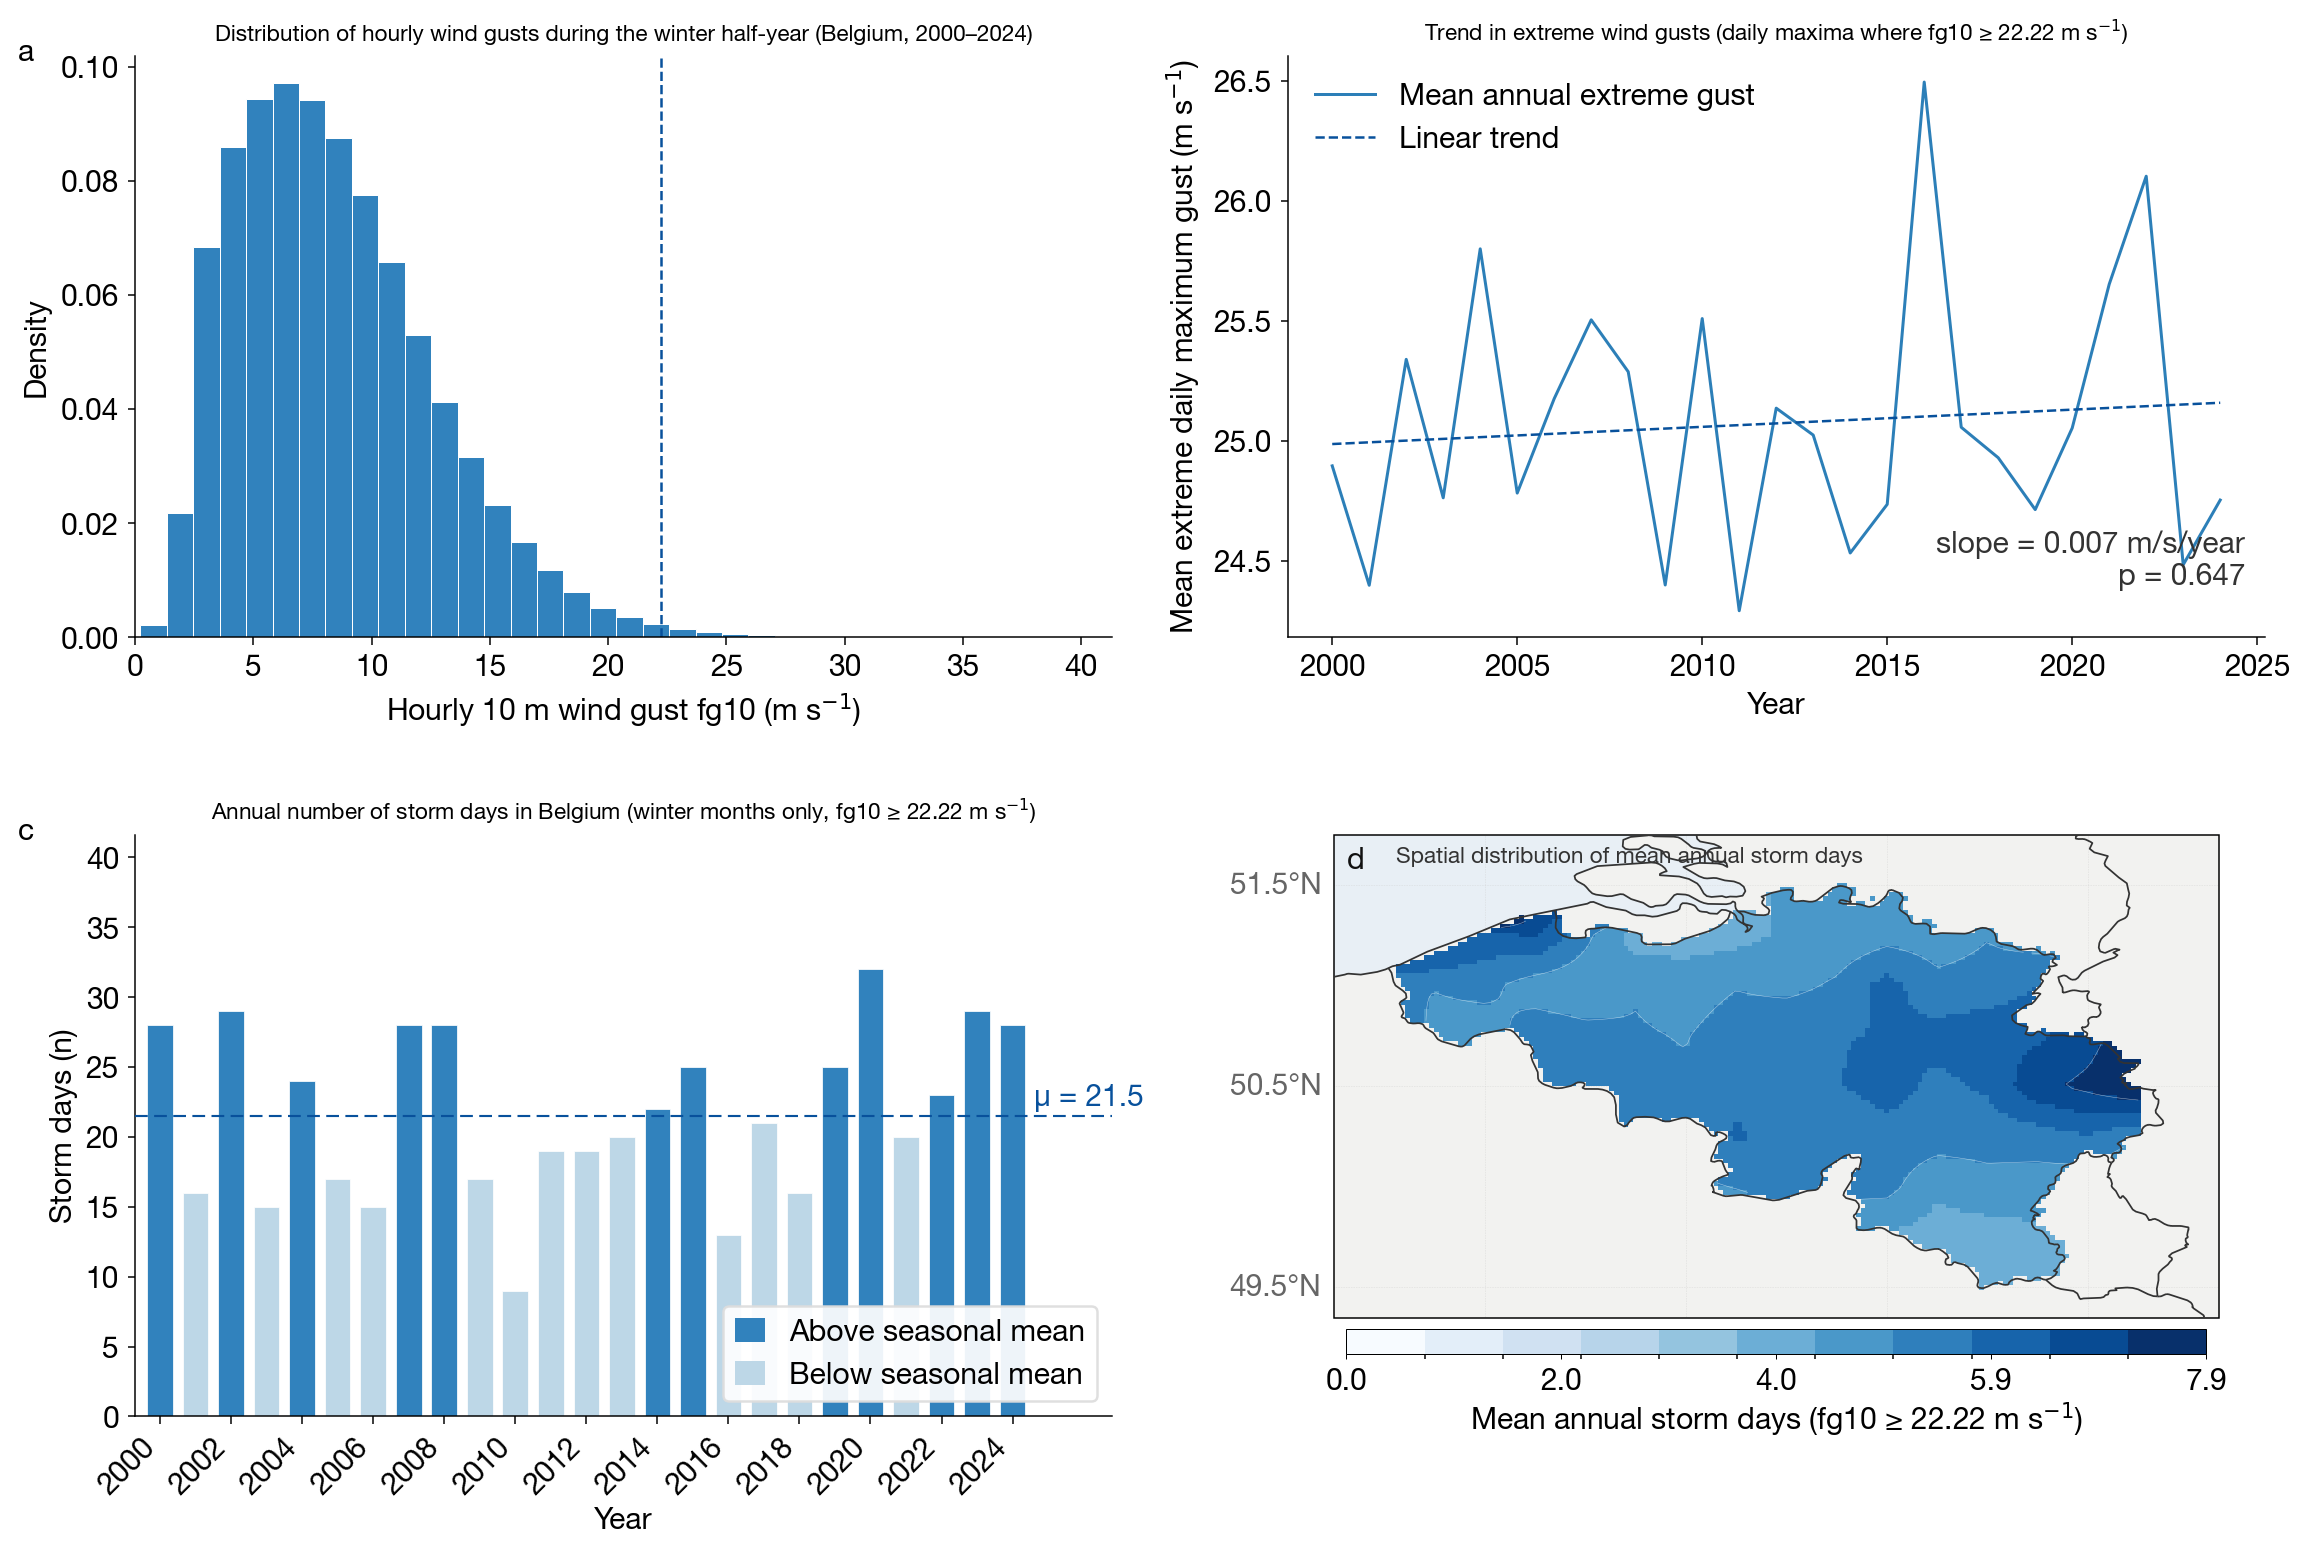

In [13]:
# ── plot ────────────────────────────────────────

def make_map(ax, letter, subtitle):
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=PROJ)

    ax.set_facecolor('white')
    ax.add_feature(cfeature.LAND.with_scale('10m'),
                   facecolor='#F2F2F0', zorder=0)
    ax.add_feature(cfeature.OCEAN.with_scale('10m'),
                   facecolor='#E8EFF5', zorder=0)

    gl = ax.gridlines(
        draw_labels=True, linewidth=0.25,
        color='#CCCCCC', linestyle=':', alpha=0.8,
        x_inline=False, y_inline=False
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LongitudeFormatter(degree_symbol='°')
    gl.yformatter = LatitudeFormatter(degree_symbol='°')

    # Alle cijfers op de kaartassen op grootte 12
    gl.xlabel_style = {'size': 12, 'color': '#666666'}
    gl.ylabel_style = {'size': 12, 'color': '#666666'}

    gl.xlocator = mticker.FixedLocator([3, 4, 5, 6])
    gl.ylocator = mticker.FixedLocator([49.5, 50.5, 51.5])

    ax.add_feature(cfeature.BORDERS.with_scale('10m'),
                   linewidth=0.7, edgecolor='#333333', zorder=6)
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'),
                   linewidth=0.7, edgecolor='#333333', zorder=6)

    ax.text(0.015, 0.975, letter, transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top',
            color='#111111', zorder=10)

    # Tussentitel van kaart kleiner gezet naar 9
    ax.text(0.07, 0.975, subtitle, transform=ax.transAxes,
            fontsize=9, va='top', color='#333333', zorder=10)


def plot_masked(ax, lon_f, lat_f, data_m, cmap, levels, extend='neither'):
    masked = np.ma.masked_invalid(data_m)
    norm = BoundaryNorm(levels, cmap.N, extend=extend)
    LON2, LAT2 = np.meshgrid(lon_f, lat_f)

    im = ax.pcolormesh(
        LON2, LAT2, masked,
        cmap=cmap, norm=norm,
        transform=PROJ, shading='auto',
        zorder=2, rasterized=True
    )

    valid_levels = levels[1:-1:3]
    if len(valid_levels) > 0:
        ax.contour(
            LON2, LAT2, masked,
            levels=valid_levels,
            colors='white', linewidths=0.2,
            transform=PROJ, zorder=3, alpha=0.6
        )
    return im


def nice_colorbar(fig, ax, im, label, levels, extend='neither'):
    cb = fig.colorbar(
        im, ax=ax, orientation='horizontal',
        pad=0.02, shrink=0.88, aspect=35, extend=extend
    )

    cb.set_label(label, fontsize=12, labelpad=2)

    # Alle cijfers op de colorbar op grootte 12
    cb.ax.tick_params(labelsize=12, width=0.4, length=2)

    cb.outline.set_linewidth(0.4)
    ticks = np.linspace(levels[0], levels[-1], 5)
    cb.set_ticks(ticks)
    cb.ax.set_xticklabels([f'{t:.1f}' for t in ticks], fontsize=12)

    return cb


# Blauwe kleuren voor alle panelen
COL_LINE = '#2C7FB8'
COL_TREND = '#08519C'
COL_ABOVE = '#3182BD'
COL_BELOW = '#BDD7E7'
COL_MEAN = '#08519C'

fig = plt.figure(figsize=(13, 9))
gs = gridspec.GridSpec(
    2, 2, figure=fig,
    hspace=0.34, wspace=0.18,
    left=0.06, right=0.97,
    top=0.92, bottom=0.08
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1], projection=PROJ)


# ── (a) Distribution of hourly gusts ──────────────────────────────────────────

ax1.hist(
    gust_hourly_flat,
    bins=35,
    density=True,
    edgecolor='white',
    linewidth=0.4,
    color=COL_ABOVE
)

ax1.axvline(
    THRESHOLD,
    color=COL_TREND,
    linestyle='--',
    linewidth=1.0
)

ax1.set_xlim(left=0)
ax1.set_xlabel('Hourly 10 m wind gust fg10 (m s$^{-1}$)', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)


ax1.set_title(
    'Distribution of hourly wind gusts during the winter half-year (Belgium, 2000–2024)',
    fontsize=9
)

ax1.text(-0.12, 1.03, 'a', transform=ax1.transAxes,
         fontsize=12, fontweight='bold', va='top')


ax1.tick_params(axis='both', labelsize=12)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)


# ── (b) Trend in extreme wind gusts ───────────────────────────────────────────

ax2.plot(
    extreme_years, extreme_values,
    linewidth=1.2, label='Mean annual extreme gust',
    color=COL_LINE
)

ax2.plot(
    extreme_years, trend_line,
    linestyle='--', linewidth=1.0, label='Linear trend',
    color=COL_TREND
)

ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Mean extreme daily maximum gust (m s$^{-1}$)', fontsize=12)

# Tussentitel kleiner gezet naar 9
ax2.set_title(
    'Trend in extreme wind gusts (daily maxima where fg10 ≥ 22.22 m s$^{-1}$)',
    fontsize=9
)

ax2.legend(frameon=False, fontsize=12, loc='upper left')

ax2.text(
    0.98, 0.08,
    f'slope = {slope:.3f} m/s/year\np = {p_value:.3f}',
    transform=ax2.transAxes,
    ha='right', va='bottom', fontsize=12, color='#333333'
)

# Cijfers op de assen op grootte 12
ax2.tick_params(axis='both', labelsize=12)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)


# ── (c) Annual storm days ─────────────────────────────────────────────────────

mean_c = counts.mean()
colors3 = [COL_ABOVE if c > mean_c else COL_BELOW for c in counts]

ax3.bar(
    seasons, counts,
    color=colors3, width=0.72,
    edgecolor='white', linewidth=0.3, zorder=2
)

ax3.axhline(
    mean_c, color=COL_MEAN, linewidth=0.85,
    linestyle=(0, (6, 3)), zorder=3
)

ax3.text(
    seasons[-1] + 0.6,
    mean_c + counts.max() * 0.04,
    f'μ = {mean_c:.1f}',
    va='center', ha='left',
    fontsize=12, color=COL_MEAN
)

ax3.legend(
    handles=[
        mpatches.Patch(fc=COL_ABOVE, ec='none', label='Above seasonal mean'),
        mpatches.Patch(fc=COL_BELOW, ec='none', label='Below seasonal mean'),
    ],
    loc='lower right', frameon=True, framealpha=0.92,
    edgecolor='#DDDDDD', fontsize=12,
    handlelength=1.0, handleheight=0.85
)

ax3.set_xlim(seasons[0] - 0.7, seasons[-1] + 2.8)
ax3.set_ylim(0, counts.max() * 1.30)
ax3.set_xticks(seasons[::2])

# Cijfers op de x-as op grootte 12
ax3.set_xticklabels(
    [str(s) for s in seasons[::2]],
    rotation=45,
    ha='right',
    fontsize=12
)

ax3.set_xlabel('Year', fontsize=12, labelpad=3)
ax3.set_ylabel('Storm days (n)', fontsize=12, labelpad=3)

# Tussentitel kleiner gezet naar 9
ax3.set_title(
    'Annual number of storm days in Belgium (winter months only, fg10 ≥ 22.22 m s$^{-1}$)',
    fontsize=9
)

ax3.text(-0.12, 1.03, 'c', transform=ax3.transAxes,
         fontsize=12, fontweight='bold', va='top')

# Cijfers op de y-as op grootte 12
ax3.tick_params(axis='both', labelsize=12)

ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)


# ── (d) Spatial distribution of mean storm days ───────────────────────────────

make_map(ax4, 'd', 'Spatial distribution of mean annual storm days')

valid_d = data_d[~np.isnan(data_d)]
vmax_d = float(np.nanmax(valid_d))
levels_d = np.linspace(0, vmax_d, 12)

im4 = plot_masked(ax4, lon_d, lat_d, data_d, mpl.cm.Blues, levels_d)

nice_colorbar(
    fig,
    ax4,
    im4,
    'Mean annual storm days (fg10 ≥ 22.22 m s$^{-1}$)',
    levels_d
)


# ── save each subplot separately ──────────────────────────────────────────────

fig.canvas.draw()
renderer = fig.canvas.get_renderer()

names = [
    "a_distribution_hourly_gusts",
    "b_trend_extreme_gusts",
    "c_annual_storm_days",
    "d_spatial_mean_storm_days"
]

for ax, name in zip([ax1, ax2, ax3, ax4], names):
    bbox = ax.get_tightbbox(renderer).transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(
        f"{name}.png",
        dpi=300,
        bbox_inches=bbox.expanded(1.08, 1.12)
    )
    fig.savefig(
        f"{name}.pdf",
        dpi=300,
        bbox_inches=bbox.expanded(1.08, 1.12)
    )


# ── save full figure ──────────────────────────────────────────────────────────

plt.savefig('hazard_characteristics_belgium_updated.pdf', dpi=300)
plt.savefig('hazard_characteristics_belgium_updated.png', dpi=300)

print('✓ saved hazard_characteristics_belgium_updated.pdf / .png')

plt.show()